# LLR Comparison: Base ESM2 vs LoRA-Finetuned (per-pfam)

Loads the LoRA delta weights produced by `ESM_domainome_ft_pfam.ipynb` for each pfam,
recomputes per-domain LLR matrices with both the un-finetuned base model and the
finetuned model for that pfam, and uploads one gzipped pickle per pfam to GCS:
`{domain_id: {sequence, seq_offset, base_llr, ft_llr, delta_llr, ...}}`.

Output paths mirror the training run, i.e. one
`llr_comparison_all.pkl.gz` per pfam under
`gs://{bucket}/{prefix}/global_finetune/{pfam_id}/`.


In [4]:
# !pip install -q -U "torchao>=0.16.0"

In [86]:
import os
import io
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import torch

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from tqdm import tqdm

from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match training run) ─────────────────────────────

# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "plm-study-484223-e1c13b49d132.json"

OUTPUT_DIR     = "finetuned_models_v2"
RUN_ID_PREFIX  = "global_finetune"   # matches training notebook's run_id = f"{RUN_ID_PREFIX}/{pfam_id}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_per_pfam/"   # must end with /

LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(pfam_id):
    """Resolve all per-pfam local + GCS paths from a pfam id."""
    run_id  = f"{RUN_ID_PREFIX}/{pfam_id}"
    run_dir = os.path.join(OUTPUT_DIR, run_id)
    # os.makedirs(run_dir, exist_ok=True)
    return {
        "run_id":        run_id,
        "run_dir":       run_dir,
        "metadata_local": os.path.join(run_dir, "metadata.json"),
        "lora_local":    os.path.join(run_dir, "best_model_lora.pth"),
        "llr_local":     os.path.join(run_dir, LLR_OUTPUT_NAME),
        "gcs_metadata":  f"{GCS_OUTPUT_PREFIX}{run_id}/metadata.json",
        "gcs_lora":      f"{GCS_OUTPUT_PREFIX}{run_id}/best_model_lora.pth",
        "gcs_llr":       f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ='plm-study-484223-e1c13b49d132.json'

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [4]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model


def recover_domains_from_metadata(metadata):
    """Pull per-domain {sequence, seq_offset, ...} out of a pfam's metadata.json.

    The training notebook writes a `domains` block per pfam that already
    contains the truncated input sequence and seq_offset used at training time,
    so we just normalize the fields here.
    """
    out = {}
    meta_domains = metadata.get("domains") or {}
    for domain_id, dinfo in meta_domains.items():
        if not isinstance(dinfo, dict) or "sequence" not in dinfo:
            continue
        out[domain_id] = {
            "uniprot_id":           dinfo.get("uniprot_id"),
            "sequence":             dinfo["sequence"],
            "seq_offset":           int(dinfo.get("seq_offset", 0)),
            "used_full_protein":    bool(dinfo.get("used_full_protein", False)),
            "dom_start_in_protein": int(dinfo.get("dom_start_in_protein", 0)),
        }
    return out

def gcs_download_bytes(gcs_path, bucket_name=GCS_BUCKET):
    """
    Download a GCS object directly into memory as bytes.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    return blob.download_as_bytes()


def gcs_upload_bytes(
    gcs_path,
    data_bytes,
    bucket_name=GCS_BUCKET,
    content_type=None
):
    """
    Upload raw bytes directly to GCS from memory.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    blob.upload_from_file(
        io.BytesIO(data_bytes),
        size=len(data_bytes),
        content_type=content_type
    )

In [74]:
def spearman_ignore_nan(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()

    mask = ~np.isnan(a) & ~np.isnan(b)

    if mask.sum() < 2:
        return np.nan

    return spearmanr(a[mask], b[mask]).statistic

def align_fitness_matrix(fitness, original_order=FITNESS_AA_ORDER, target_order=AA_ORDER):
    mat = np.array(fitness)

    # Case 1: amino acids are rows (20 × L)
    if mat.shape[0] == 20:
        idx_map = {aa: i for i, aa in enumerate(original_order)}
        reorder = [idx_map[aa] for aa in target_order]
        return mat[reorder, :]

    # Case 2: amino acids are columns (L × 20)
    elif mat.shape[1] == 20:
        idx_map = {aa: i for i, aa in enumerate(original_order)}
        reorder = [idx_map[aa] for aa in target_order]
        return mat[:, reorder]

    else:
        raise ValueError(f"Unexpected fitness shape: {mat.shape}")

In [6]:
# ── Discover pfams from GCS ──────────────────────────────────────────────────
#
# The training notebook writes one directory per pfam under
# `GCS_OUTPUT_PREFIX{RUN_ID_PREFIX}/{pfam_id}/` (each containing a
# `metadata.json` + `best_model_lora.pth`). We list those blobs and recover
# the set of pfam ids that have a finetuned model available.

_run_prefix = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/"

PFAM_IDS = sorted({
    blob.name[len(_run_prefix):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=_run_prefix)
    if blob.name.endswith("/metadata.json")
})

print(f"Found {len(PFAM_IDS)} pfams under gs://{GCS_BUCKET}/{_run_prefix}")
print(PFAM_IDS[:10], "..." if len(PFAM_IDS) > 10 else "")


Found 126 pfams under gs://domainome-data/ESM2/ft_per_pfam/global_finetune/
['PF00010', 'PF00013', 'PF00018', 'PF00030', 'PF00035', 'PF00046', 'PF00096', 'PF00105', 'PF00130', 'PF00157'] ...


## Reload a pfam's comparison dict

```python
import gzip, io, pickle, pandas as pd
from google.cloud import storage

pfam_id = "PF00001"  # pick one

blob = storage.Client().bucket("<bucket>").blob(
    f"<prefix>/global_finetune/{pfam_id}/llr_comparison_all.pkl.gz"
)
with gzip.open(io.BytesIO(blob.download_as_bytes()), "rb") as gz:
    payload = pickle.load(gz)

entry    = payload["domains"]["<domain_id>"]
base_df  = pd.DataFrame(entry["base_llr"],  index=entry["aa_order"], columns=entry["positions"])
ft_df    = pd.DataFrame(entry["ft_llr"],    index=entry["aa_order"], columns=entry["positions"])
delta_df = pd.DataFrame(entry["delta_llr"], index=entry["aa_order"], columns=entry["positions"])
```


In [2]:
# pip install -U numpy

In [3]:
# import numpy as np
# print(np.__version__)
# 1.26.4

In [7]:
# ── Build a single DataFrame with all values from every pfam's ──────────────
# ── llr_comparison_all.pkl.gz on GCS (streamed, no local files) ──────────────
#
# For each pfam folder under `gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/`,
# stream `llr_comparison_all.pkl.gz` straight from GCS into memory, unpickle
# it, flatten `payload["domains"]` into one row per domain, and concatenate
# every pfam into a single `llr_df` DataFrame. Matrix/array fields
# (`base_llr`, `ft_llr`, `delta_llr`, ...) are kept as numpy arrays in object
# columns; any top-level payload metadata (everything in the payload except
# `"domains"`) is prefixed with `pfam_` and broadcast across that pfam's rows.

_rows = []
_missing = []

for pfam_id in tqdm(PFAM_IDS, desc="Loading llr_comparison_all.pkl.gz"):
    gcs_blob_path = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/{pfam_id}/{LLR_OUTPUT_NAME}"
    try:
        payload = gcs_download_pickle_gz(_gcs_bucket.blob(gcs_blob_path))
    except Exception as exc:
        _missing.append((pfam_id, str(exc)))
        continue

    pfam_meta = {f"pfam_{k}": v for k, v in payload.items() if k != "domains"}

    for domain_id, entry in payload.get("domains", {}).items():
        row = {"pfam_id": pfam_id, "domain_id": domain_id}
        row.update(pfam_meta)
        row.update(entry)
        _rows.append(row)

llr_df = pd.DataFrame(_rows)

print(f"Loaded {len(llr_df)} domain rows across {llr_df['pfam_id'].nunique()} pfams")
if _missing:
    print(f"Skipped {len(_missing)} pfams (first 5): {_missing[:5]}")
print("Columns:", list(llr_df.columns))
llr_df.head()


Loading llr_comparison_all.pkl.gz: 100%|██████████| 126/126 [33:35<00:00, 16.00s/it] 


Loaded 65772 domain rows across 126 pfams
Columns: ['pfam_id', 'domain_id', 'pfam_run_id', 'pfam_pfam_id', 'pfam_model_name', 'pfam_best_config', 'pfam_aa_order', 'pfam_n_domains', 'pfam_n_train_domains', 'uniprot_id', 'sequence', 'seq_offset', 'used_full_protein', 'dom_start_in_protein', 'aa_order', 'positions', 'base_llr', 'ft_llr', 'delta_llr', 'in_pfam_train']


,pfam_id,domain_id,pfam_run_id,pfam_pfam_id,pfam_model_name,pfam_best_config,pfam_aa_order,pfam_n_domains,pfam_n_train_domains,uniprot_id,sequence,seq_offset,used_full_protein,dom_start_in_protein,aa_order,positions,base_llr,ft_llr,delta_llr,in_pfam_train
0,PF00010,A0A2R8Y422_PF00240_2,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0A2R8Y422,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[Q 1, I 2, F 3, V 4, K 5, T 6, L 7, M 8, G 9, ...","[[-3.5157275, -5.9415855, -8.149918, -5.678594...","[[-4.2675524, -4.7696867, -4.3836045, -4.11129...","[[-0.75182486, 1.1718988, 3.766313, 1.5672965,...",False
1,PF00010,A0PJY2_PF00096_289,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0PJY2,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,0,True,288,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, D 2, S 3, S 4, C 5, H 6, N 7, A 8, T 9, ...","[[-7.877233, -3.0762224, -3.9222503, -3.706128...","[[-7.9733877, -2.7160609, -3.8156652, -3.67532...","[[-0.09615469, 0.36016154, 0.106585026, 0.0308...",False
2,PF00010,A1X283_PF00018_155,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,0,True,154,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False
3,PF00010,A1X283_PF00018_222,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,0,True,221,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False
4,PF00010,A2RRE5_PF01846_267,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A2RRE5,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[S 1, Q 2, Q 3, I 4, A 5, T 6, A 7, K 8, D 9, ...","[[-2.97742, -3.6223297, -3.273647, -3.0311143,...","[[-2.7942326, -2.8969717, -2.461637, -2.973482...","[[0.18318748, 0.725358, 0.81201005, 0.05763173...",False


In [57]:
llr_df.iloc[43]

model_pfam                                                        PF00010
domain_id                                              O60885_PF17035_607
pfam_run_id                                       global_finetune/PF00010
pfam_pfam_id                                                      PF00010
pfam_model_name                              facebook/esm2_t33_650M_UR50D
pfam_best_config          {'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}
pfam_aa_order           [L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...
pfam_n_domains                                                        522
pfam_n_train_domains                                                    2
uniprot_id                                                         O60885
sequence                FNTMFTNCYIYNKPGDDIVLMAEALEKLFLQKINELPTEETEIMIV...
seq_offset                                                            128
used_full_protein                                                    True
dom_start                             

In [8]:
llr_df.rename(columns={'pfam_id':'model_pfam'},inplace=True)

In [10]:
llr_df['input_pfam'] = llr_df['domain_id'].str.split("_").str[1]

In [11]:
llr_df.head()

,model_pfam,domain_id,pfam_run_id,pfam_pfam_id,pfam_model_name,pfam_best_config,pfam_aa_order,pfam_n_domains,pfam_n_train_domains,uniprot_id,...,seq_offset,used_full_protein,dom_start_in_protein,aa_order,positions,base_llr,ft_llr,delta_llr,in_pfam_train,input_pfam
0,PF00010,A0A2R8Y422_PF00240_2,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0A2R8Y422,...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[Q 1, I 2, F 3, V 4, K 5, T 6, L 7, M 8, G 9, ...","[[-3.5157275, -5.9415855, -8.149918, -5.678594...","[[-4.2675524, -4.7696867, -4.3836045, -4.11129...","[[-0.75182486, 1.1718988, 3.766313, 1.5672965,...",False,PF00240
1,PF00010,A0PJY2_PF00096_289,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0PJY2,...,0,True,288,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, D 2, S 3, S 4, C 5, H 6, N 7, A 8, T 9, ...","[[-7.877233, -3.0762224, -3.9222503, -3.706128...","[[-7.9733877, -2.7160609, -3.8156652, -3.67532...","[[-0.09615469, 0.36016154, 0.106585026, 0.0308...",False,PF00096
2,PF00010,A1X283_PF00018_155,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,...,0,True,154,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,PF00018
3,PF00010,A1X283_PF00018_222,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,...,0,True,221,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,PF00018
4,PF00010,A2RRE5_PF01846_267,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A2RRE5,...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[S 1, Q 2, Q 3, I 4, A 5, T 6, A 7, K 8, D 9, ...","[[-2.97742, -3.6223297, -3.273647, -3.0311143,...","[[-2.7942326, -2.8969717, -2.461637, -2.973482...","[[0.18318748, 0.725358, 0.81201005, 0.05763173...",False,PF01846


In [12]:
llr_df.columns

Index(['model_pfam', 'domain_id', 'pfam_run_id', 'pfam_pfam_id',
       'pfam_model_name', 'pfam_best_config', 'pfam_aa_order',
       'pfam_n_domains', 'pfam_n_train_domains', 'uniprot_id', 'sequence',
       'seq_offset', 'used_full_protein', 'dom_start_in_protein', 'aa_order',
       'positions', 'base_llr', 'ft_llr', 'delta_llr', 'in_pfam_train',
       'input_pfam'],
      dtype='object')

In [13]:
llr_df.rename(columns={'dom_start_in_protein':'dom_start'},inplace=True)

In [14]:
clean_llr_df = llr_df[['model_pfam', 'domain_id', 'input_pfam', 'base_llr', 'ft_llr', 'delta_llr', 'dom_start', 'sequence', 'in_pfam_train', 'used_full_protein', 'pfam_best_config']]

In [15]:
clean_llr_df["n_dom_per_model_pfam"] = (
    clean_llr_df.groupby(["model_pfam", "input_pfam"])["domain_id"]
      .transform("count")
)

In [16]:
blob = _gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB)
data_bytes = blob.download_as_bytes()

with gzip.GzipFile(fileobj=io.BytesIO(data_bytes), mode="rb") as f:
    fitness_dict = pickle.load(f)

print(type(fitness_dict))
print(len(fitness_dict))

<class 'dict'>
522


In [17]:
aa_to_idx = {aa: i for i, aa in enumerate(FITNESS_AA_ORDER)}
target_idx = [aa_to_idx[aa] for aa in AA_ORDER]

In [18]:
clean_llr_df["fitness_matrix_aligned"] = clean_llr_df["domain_id"].map(
    lambda d: align_fitness_matrix(fitness_dict[d]["fitness"])
)

In [19]:
clean_llr_df['dom_seq'] = clean_llr_df["domain_id"].map(
    lambda d: fitness_dict[d]["dom_seq"]
)

In [39]:
clean_llr_df.head()

,model_pfam,domain_id,input_pfam,base_llr,ft_llr,delta_llr,dom_start,sequence,in_pfam_train,used_full_protein,pfam_best_config,n_dom_per_model_pfam,fitness_matrix_aligned,dom_seq,dom_len
2630,PF00046,O14813_PF00046_92,PF00046,"[[-8.989872, -4.4976473, -3.4166539, -4.522572...","[[-6.614028, -2.5438247, -2.060439, -2.9358675...","[[2.375844, 1.9538226, 1.3562148, 1.586705, 1....",91,MDYSYLNSYDSCVAAMEASAYGDFGACSQPGGFQYSPLRPAFPAAG...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[0.067906459080596, -0.252845686004381, -0.07...",RIRTTFTSAQLKELERVFAETHYPDIYTREELALKIDLTEARVQVW...,56
2636,PF00046,O15266_PF00046_119,PF00046,"[[-7.7596188, -4.4323206, -3.7878857, 0.0, -3....","[[-6.372239, -3.4937015, -3.1961832, 0.0, -2.5...","[[1.3873796, 0.93861914, 0.59170246, 0.0, 0.46...",118,MEELTAFVSKSFDQKSKDGNGGGGGGGGKKDSITYREVLESGLARS...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.282731125117935, -0.524680293042792, 0.05...",RSRTNFTLEQLNELERLFDETHYPDAFMREELSQRLGLSEARVQVW...,56
2643,PF00046,O43186_PF00046_41,PF00046,"[[-7.7250752, -3.3352969, -4.799062, -2.774308...","[[-5.68833, -0.9341475, -3.2170742, -1.7889, -...","[[2.036745, 2.4011493, 1.5819876, 0.98540866, ...",40,MMAYMNPGPHYSVNALALSGPSVDLMHQAVPYPSAPRKQRRERTTF...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.189065756029478, -0.298403672881698, 0.01...",RERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVW...,56
2655,PF00046,O75360_PF00046_71,PF00046,"[[-8.499002, -4.8615136, -4.242122, -4.32531, ...","[[-6.9526515, -3.6529894, -3.597206, -3.574699...","[[1.546351, 1.2085242, 0.64491606, 0.7506113, ...",70,MEAERRRQAEKPKKGRVGSNLLPERHPATGTPTTTVDSSAPPCRRL...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.30002287290244, -0.204713259556305, 0.063...",RHRTTFSPVQLEQLESAFGRNQYPDIWARESLARDTGLSEARIQVW...,56
2682,PF00046,O95076_PF00046_155,PF00046,"[[-8.572465, -3.3529034, -3.920962, -2.428968,...","[[-6.3206973, -2.6541457, -3.346086, -2.508753...","[[2.2517676, 0.69875765, 0.57487607, -0.079785...",154,MDPEHCAPFRVGPAPGPYVASGDEPPGPQGTPAAAPHLHPAPPRGP...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.0914627263905966, -0.203559809638724, -0....",RNRTTFSTFQLEELEKVFQKTHYPDVYAREQLALRTDLTEARVQVW...,56


In [27]:
llr_cols = ["fitness_matrix_aligned"]

for col in llr_cols:
    clean_llr_df[col] = clean_llr_df[col].apply(
        lambda x: np.asarray(x).T
    )

In [28]:
for i in range(5):
    print(clean_llr_df['ft_llr'].iloc[i].shape)
    print(clean_llr_df['fitness_matrix_aligned'].iloc[i].shape)
    print(len(clean_llr_df['dom_seq'].iloc[i]))
    print()

(20, 70)
(20, 70)
70

(20, 475)
(20, 22)
22

(20, 911)
(20, 55)
55

(20, 911)
(20, 59)
59

(20, 63)
(20, 63)
63



In [34]:
for i in range(5):
    dom_start = clean_llr_df['dom_start'].iloc[i]
    dom_len = len(clean_llr_df['dom_seq'].iloc[i])
    dom_seq = clean_llr_df['dom_seq'].iloc[i]
    seq = clean_llr_df['sequence'].iloc[i]


    print(clean_llr_df['ft_llr'].iloc[i].shape)
    print(clean_llr_df['ft_llr'].iloc[i][:, dom_start: dom_start + dom_len].shape)
    print(clean_llr_df['fitness_matrix_aligned'].iloc[i].shape)
    print(dom_len)
    print(dom_seq)
    print(seq[dom_start: dom_start + dom_len])
    print()

(20, 70)
(20, 70)
(20, 70)
70
QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVL
QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVL

(20, 475)
(20, 22)
(20, 22)
22
VCKVCGKGFRQASTLCRHKIIH
VCKVCGKGFRQASTLCRHKIIH

(20, 911)
(20, 55)
(20, 55)
55
EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGWVPATCLEGQ
EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGWVPATCLEGQ

(20, 911)
(20, 59)
(20, 59)
59
EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKEGWAPASYLKKNSG
EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKEGWAPASYLKKNSG

(20, 63)
(20, 63)
(20, 63)
63
SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLEGTQKAKKLFLQHIHRLK
SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLEGTQKAKKLFLQHIHRLK



In [38]:
clean_llr_df['dom_len'] = clean_llr_df['dom_seq'].str.len()

In [40]:
clean_llr_df['dom_len'].nunique()

75

In [44]:
for i in range(50):
    print(len(clean_llr_df['dom_seq'].iloc[i]), clean_llr_df['dom_len'].iloc[i])

56 56
56 56
56 56
56 56
56 56
51 51
51 51
53 53
56 56
56 56
56 56
55 55
56 56
56 56
56 56
56 56
56 56
56 56
56 56
55 55
50 50
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
56 56
41 41
50 50
56 56
55 55
59 59
60 60
58 58
56 56
57 57
58 58
58 58
61 61
59 59
58 58
57 57
66 66


In [68]:
# clean_llr_df['base_llr_dom'] = clean_llr_df.apply(
#     lambda row: np.asarray(row['base_llr'])[
#         :,
#         row['dom_start']:row['dom_start'] + row['dom_len']
#     ],
#     axis=1
# )

clean_llr_df['base_llr_dom'] = clean_llr_df.apply(
    lambda row: np.asarray(row['base_llr'])[
        :,
        row['sequence'].find(row['dom_seq']):row['sequence'].find(row['dom_seq']) + row['dom_len']
    ],
    axis=1
)

In [67]:
# clean_llr_df['ft_llr_dom'] = clean_llr_df.apply(
#     lambda row: np.asarray(row['ft_llr'])[
#         :,
#         row['dom_start']:row['dom_start'] + row['dom_len']
#     ],
#     axis=1
# )

clean_llr_df['ft_llr_dom'] = clean_llr_df.apply(
    lambda row: np.asarray(row['ft_llr'])[
        :,
        row['sequence'].find(row['dom_seq']):row['sequence'].find(row['dom_seq']) + row['dom_len']
    ],
    axis=1
)

In [70]:
for i in range(43,44):
    dom_start = clean_llr_df['dom_start'].iloc[i]
    dom_len = len(clean_llr_df['dom_seq'].iloc[i])
    dom_seq = clean_llr_df['dom_seq'].iloc[i]
    seq = clean_llr_df['sequence'].iloc[i]

    print(i)
    print(dom_start-128)
    print(clean_llr_df['ft_llr'].iloc[i].shape)
    print(clean_llr_df['ft_llr'].iloc[i][:, dom_start: dom_start + dom_len].shape)
    print(clean_llr_df['fitness_matrix_aligned'].iloc[i].shape)
    print(clean_llr_df['base_llr_dom'].iloc[i].shape)
    print(dom_len)
    print(dom_seq)
    print(seq[seq.find(dom_seq): seq.find(dom_seq) + dom_len])
    print()

43
850
(20, 1022)
(20, 44)
(20, 58)
(20, 58)
58
EQRVMALYDFQARSPREVTMKKGDVLTLLSSINKDWWKVEAADHQGIVPAVYVRRLAH
EQRVMALYDFQARSPREVTMKKGDVLTLLSSINKDWWKVEAADHQGIVPAVYVRRLAH



In [66]:
dom_seq = 'EQRVMALYDFQARSPREVTMKKGDVLTLLSSINKDWWKVEAADHQGIVPAVYVRRLAH'
seq = clean_llr_df['sequence'].iloc[43]

seq.find(dom_seq)

483

In [35]:
pfam_scores = (
    clean_llr_df.groupby("model_pfam")["n_dom_per_model_pfam"].sum()
    .add(
        clean_llr_df.groupby("input_pfam")["n_dom_per_model_pfam"].sum(),
        fill_value=0
    )
    .sort_values(ascending=False)
)

In [36]:
pfam_order = pfam_scores.index

clean_llr_df["model_pfam"] = pd.Categorical(clean_llr_df["model_pfam"], categories=pfam_order, ordered=True)
clean_llr_df["input_pfam"] = pd.Categorical(clean_llr_df["input_pfam"], categories=pfam_order, ordered=True)

In [37]:
clean_llr_df = clean_llr_df.sort_values(
    by=["model_pfam", "input_pfam", "domain_id"],
    ascending=[True, True, True]
)

In [55]:
i = 42

spearman_flat(clean_llr_df['base_llr_dom'].iloc[i], clean_llr_df['fitness_matrix_aligned'].iloc[i])

np.float64(0.4979784660684582)

In [75]:
clean_llr_df['base_spearman'] = clean_llr_df.apply(
    lambda row: spearman_ignore_nan(
        row['base_llr_dom'],
        row['fitness_matrix_aligned']
    ),
    axis=1
)

In [77]:
clean_llr_df['ft_spearman'] = clean_llr_df.apply(
    lambda row: spearman_ignore_nan(
        row['ft_llr_dom'],
        row['fitness_matrix_aligned']
    ),
    axis=1
)

In [84]:
clean_llr_df.head()

,model_pfam,domain_id,input_pfam,base_llr,ft_llr,delta_llr,dom_start,sequence,in_pfam_train,used_full_protein,pfam_best_config,n_dom_per_model_pfam,fitness_matrix_aligned,dom_seq,dom_len,base_llr_dom,ft_llr_dom,base_spearman,ft_spearman,diff_spearman
2630,PF00046,O14813_PF00046_92,PF00046,"[[-8.989872, -4.4976473, -3.4166539, -4.522572...","[[-6.614028, -2.5438247, -2.060439, -2.9358675...","[[2.375844, 1.9538226, 1.3562148, 1.586705, 1....",91,MDYSYLNSYDSCVAAMEASAYGDFGACSQPGGFQYSPLRPAFPAAG...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[0.067906459080596, -0.252845686004381, -0.07...",RIRTTFTSAQLKELERVFAETHYPDIYTREELALKIDLTEARVQVW...,56,"[[-11.365372, -4.964893, -13.621617, -12.23509...","[[0.6764276, 0.6954026, 0.18087661, 0.47145915...",0.456540,0.359563,-0.096978
2636,PF00046,O15266_PF00046_119,PF00046,"[[-7.7596188, -4.4323206, -3.7878857, 0.0, -3....","[[-6.372239, -3.4937015, -3.1961832, 0.0, -2.5...","[[1.3873796, 0.93861914, 0.59170246, 0.0, 0.46...",118,MEELTAFVSKSFDQKSKDGNGGGGGGGGKKDSITYREVLESGLARS...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.282731125117935, -0.524680293042792, 0.05...",RSRTNFTLEQLNELERLFDETHYPDAFMREELSQRLGLSEARVQVW...,56,"[[-9.9522295, -5.150018, -13.030891, -11.20859...","[[0.85798097, -1.0819936, 0.33800673, 0.667457...",0.438627,0.354684,-0.083943
2643,PF00046,O43186_PF00046_41,PF00046,"[[-7.7250752, -3.3352969, -4.799062, -2.774308...","[[-5.68833, -0.9341475, -3.2170742, -1.7889, -...","[[2.036745, 2.4011493, 1.5819876, 0.98540866, ...",40,MMAYMNPGPHYSVNALALSGPSVDLMHQAVPYPSAPRKQRRERTTF...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.189065756029478, -0.298403672881698, 0.01...",RERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVW...,56,"[[-11.685195, -4.4393744, -14.016017, -11.0067...","[[0.8201685, -0.7017852, -0.57013285, 0.371886...",0.493978,0.292624,-0.201355
2655,PF00046,O75360_PF00046_71,PF00046,"[[-8.499002, -4.8615136, -4.242122, -4.32531, ...","[[-6.9526515, -3.6529894, -3.597206, -3.574699...","[[1.546351, 1.2085242, 0.64491606, 0.7506113, ...",70,MEAERRRQAEKPKKGRVGSNLLPERHPATGTPTTTVDSSAPPCRRL...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.30002287290244, -0.204713259556305, 0.063...",RHRTTFSPVQLEQLESAFGRNQYPDIWARESLARDTGLSEARIQVW...,56,"[[-9.980609, -1.1963998, -11.446607, -10.71689...","[[0.8088951, 0.31992388, -0.08340323, 0.698841...",0.416783,0.328298,-0.088485
2682,PF00046,O95076_PF00046_155,PF00046,"[[-8.572465, -3.3529034, -3.920962, -2.428968,...","[[-6.3206973, -2.6541457, -3.346086, -2.508753...","[[2.2517676, 0.69875765, 0.57487607, -0.079785...",154,MDPEHCAPFRVGPAPGPYVASGDEPPGPQGTPAAAPHLHPAPPRGP...,True,True,"{'lr': 0.005, 'lora_r': 16, 'lora_alpha': 32}",37,"[[-0.0914627263905966, -0.203559809638724, -0....",RNRTTFSTFQLEELEKVFQKTHYPDVYAREQLALRTDLTEARVQVW...,56,"[[-9.198722, -4.7757077, -11.769524, -11.72338...","[[0.8898196, -0.41826296, 0.32506156, 0.719201...",0.392767,0.316624,-0.076143


In [79]:
clean_llr_df['diff_spearman'] = clean_llr_df['ft_spearman'] - clean_llr_df['base_spearman']

In [82]:
clean_llr_df[clean_llr_df['model_pfam']==clean_llr_df['input_pfam']].describe()

,dom_start,n_dom_per_model_pfam,dom_len,base_spearman,ft_spearman,diff_spearman
count,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000
mean,437.398844,15.558767,57.788054,0.449752,0.494541,0.044788
std,634.749515,13.312835,18.763859,0.139753,0.153023,0.128533
min,0.000000,1.000000,19.000000,0.026799,-0.052528,-0.482697
25%,93.500000,3.000000,45.500000,0.355820,0.391994,-0.002706
50%,265.000000,10.000000,58.000000,0.449195,0.515071,0.027114
75%,553.500000,31.000000,70.500000,0.547327,0.610128,0.103970
max,8464.000000,37.000000,97.000000,0.760928,0.838448,0.512467


In [83]:
clean_llr_df.describe()

,dom_start,n_dom_per_model_pfam,dom_len,base_spearman,ft_spearman,diff_spearman
count,65772.000000,65772.000000,65772.000000,65772.000000,65772.000000,65772.000000
mean,434.885057,15.486590,57.697318,0.449464,0.441742,-0.007722
std,633.181523,13.295767,18.730339,0.139365,0.159692,0.097052
min,0.000000,1.000000,19.000000,0.026799,-0.414859,-0.992379
25%,90.000000,3.000000,45.000000,0.355510,0.348718,-0.005298
50%,263.000000,10.000000,58.000000,0.448598,0.452756,0.001829
75%,553.000000,31.000000,70.000000,0.546888,0.554790,0.016681
max,8464.000000,37.000000,97.000000,0.760928,0.838448,0.529710


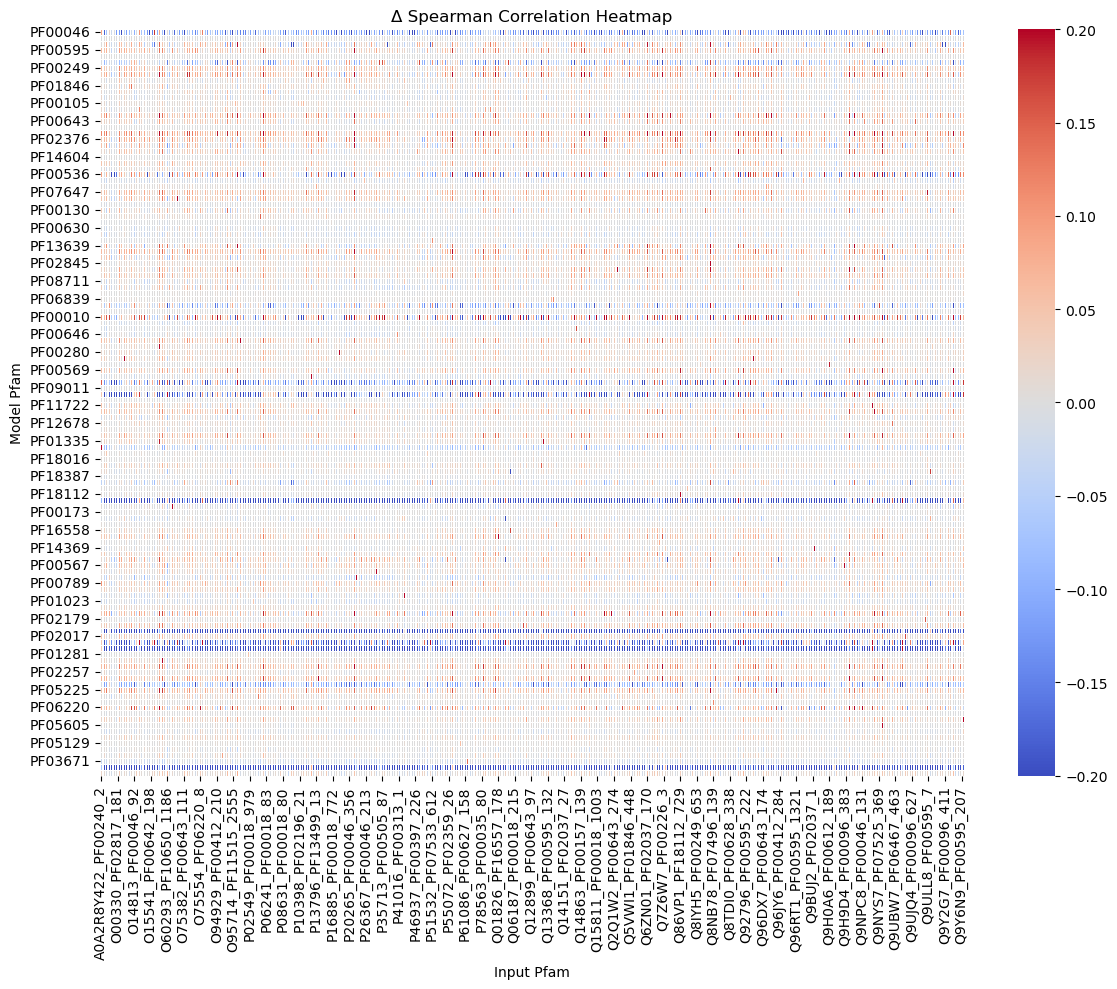

In [91]:
# Pivot into matrix form
heatmap_df = clean_llr_df.pivot(
    index='model_pfam',
    columns='domain_id',
    values='diff_spearman'
)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_df,
    cmap='coolwarm',
    center=0,
    vmin=-0.2,
    vmax=0.2,
    linewidths=0.5
)

plt.xlabel("Input Pfam")
plt.ylabel("Model Pfam")
plt.title("Δ Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

# Other stuff

In [8]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per domain × pfam ────────
#
# For every domain across every pfam in `pfam_payloads`, line up each measured
# (position, mut_aa) fitness value with the corresponding entry in the base and
# finetuned LLR matrices and compute Spearman ρ separately for base and ft.

from scipy.stats import spearmanr

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for pfam_id, payload in tqdm(pfam_payloads.items(), desc="Pfams"):
    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "pfam_id":    pfam_id,
            "domain_id":  domain_id,
            "uniprot_id": entry.get("uniprot_id"),
            "n":          int(len(fits)),
            "rho_base":   float(rho_base),
            "p_base":     float(p_base),
            "rho_ft":     float(rho_ft),
            "p_ft":       float(p_ft),
            "delta_rho":  float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} domains "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"Domains improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)


Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Pfams: 0it [00:00, ?it/s]


KeyError: 'delta_rho'

In [ ]:
corr_df.sort_values("pfam_id").head(30)

,pfam_id,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
0,PF00010,P50539_PF00010_70,P50539,939,0.271619,2.413463e-17,0.493691,7.603561e-59,0.222072
1,PF00010,Q05195_PF00010_58,Q05195,938,0.201825,4.452025e-10,0.510663,1.966802e-63,0.308838
3,PF00013,Q06787_PF00013_217,Q06787,1212,0.429986,1.027802e-55,0.460133,1.538933e-64,0.030147
2,PF00013,P61978_PF00013_385,P61978,1406,0.359444,3.920498e-44,0.415475,8.654241e-60,0.056032
10,PF00013,Q96I24_PF00013_75,Q96I24,1443,0.451784,1.704134e-73,0.655272,8.967053e-178,0.203488
4,PF00013,Q15365_PF00013_278,Q15365,1360,0.370118,2.092788e-45,0.695142,6.704938e-197,0.325024
9,PF00013,Q96AE4_PF00013_98,Q96AE4,1341,0.399393,1.614882e-52,0.594967,3.313053e-129,0.195574
8,PF00013,Q96AE4_PF00013_184,Q96AE4,1406,0.483132,4.016785e-83,0.642705,1.168421e-164,0.159573
7,PF00013,Q92945_PF00013_142,Q92945,1387,0.412251,4.940292e-58,0.653580,8.915567e-170,0.241328
6,PF00013,Q86XN8_PF00013_273,Q86XN8,1260,0.605706,5.057738e-127,0.612489,1.289988e-130,0.006783


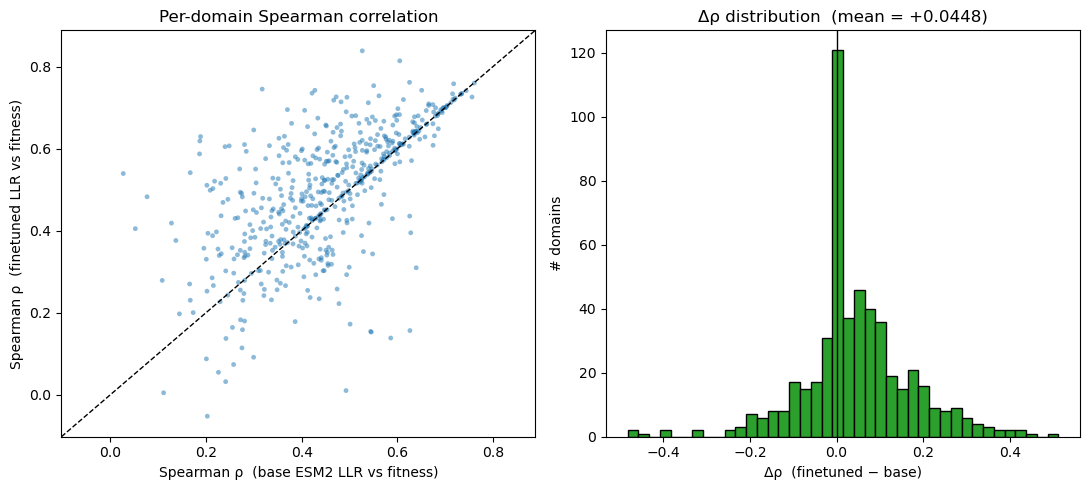

In [ ]:
# ── Plot: per-domain Spearman, base vs finetuned ─────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lo = float(min(corr_df["rho_base"].min(), corr_df["rho_ft"].min())) - 0.05
hi = float(max(corr_df["rho_base"].max(), corr_df["rho_ft"].max())) + 0.05

axes[0].scatter(corr_df["rho_base"], corr_df["rho_ft"],
                alpha=0.5, s=12, edgecolor="none")
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_xlabel("Spearman ρ  (base ESM2 LLR vs fitness)")
axes[0].set_ylabel("Spearman ρ  (finetuned LLR vs fitness)")
axes[0].set_title("Per-domain Spearman correlation")

axes[1].hist(corr_df["delta_rho"], bins=40, color="C2", edgecolor="black")
axes[1].axvline(0, color="k", linewidth=1)
axes[1].set_xlabel("Δρ  (finetuned − base)")
axes[1].set_ylabel("# domains")
axes[1].set_title(f"Δρ distribution  (mean = {corr_df['delta_rho'].mean():+.4f})")

plt.tight_layout()
plt.show()